In [1]:

!pip install imblearn --user

!pip install imbalanced-learn --user

!pip install xgboost

!pip install --upgrade xgboost scikit-learn


In [2]:
import numpy as np
from numpy import array
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

import sklearn.metrics as metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    recall_score,
    accuracy_score,
    precision_score,
    f1_score,
)

from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# To run gridsearch
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

# To undersample and oversample the data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
import xgboost
import warnings
warnings.filterwarnings("ignore")

In [3]:
heart_data = pd.read_csv('/content/data/heart_cleveland_upload.csv')

heart_data.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [4]:
heart_data = heart_data.set_axis(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'class'], axis=1)

In [5]:
# Check missing values
heart_data.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [6]:
print(heart_data['ca'].unique())
print(heart_data['thal'].unique())

[1 2 0 3]
[0 2 1]


In [7]:
# Looks like there are no missing values

In [8]:
#EDA

stat_columns = ['age','trestbps','chol','thalach','oldpeak']
heart_data[stat_columns].describe()


,age,trestbps,chol,thalach,oldpeak
count,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,131.693603,247.350168,149.599327,1.055556
std,9.049736,17.762806,51.997583,22.941562,1.166123
min,29.000000,94.000000,126.000000,71.000000,0.000000
25%,48.000000,120.000000,211.000000,133.000000,0.000000
50%,56.000000,130.000000,243.000000,153.000000,0.800000
75%,61.000000,140.000000,276.000000,166.000000,1.600000
max,77.000000,200.000000,564.000000,202.000000,6.200000


In [9]:
for col in heart_data.columns:
    heart_data[col] = pd.to_numeric(heart_data[col], errors='coerce').astype(float)

heart_data.dtypes

,0
age,float64
sex,float64
cp,float64
trestbps,float64
chol,float64
fbs,float64
restecg,float64
thalach,float64
exang,float64
oldpeak,float64


In [10]:
#Change values (1,2,3) into '1' so that class labels values are :
# Value 0: < 50% diameter narrowing --> no disease
# Value 1: > 50% diameter narrowing --> has disease

heart_data.loc[heart_data['class'].isin([1, 2, 3, 4]), 'class'] = 1

heart_data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,class
0,69.0,1.0,0.0,160.0,234.0,1.0,2.0,131.0,0.0,0.1,1.0,1.0,0.0,0.0
1,69.0,0.0,0.0,140.0,239.0,0.0,0.0,151.0,0.0,1.8,0.0,2.0,0.0,0.0
2,66.0,0.0,0.0,150.0,226.0,0.0,0.0,114.0,0.0,2.6,2.0,0.0,0.0,0.0
3,65.0,1.0,0.0,138.0,282.0,1.0,2.0,174.0,0.0,1.4,1.0,1.0,0.0,1.0
4,64.0,1.0,0.0,110.0,211.0,0.0,2.0,144.0,1.0,1.8,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,40.0,1.0,3.0,152.0,223.0,0.0,0.0,181.0,0.0,0.0,0.0,0.0,2.0,1.0
293,39.0,1.0,3.0,118.0,219.0,0.0,0.0,140.0,0.0,1.2,1.0,0.0,2.0,1.0
294,35.0,1.0,3.0,120.0,198.0,0.0,0.0,130.0,1.0,1.6,1.0,0.0,2.0,1.0
295,35.0,0.0,3.0,138.0,183.0,0.0,0.0,182.0,0.0,1.4,0.0,0.0,0.0,0.0


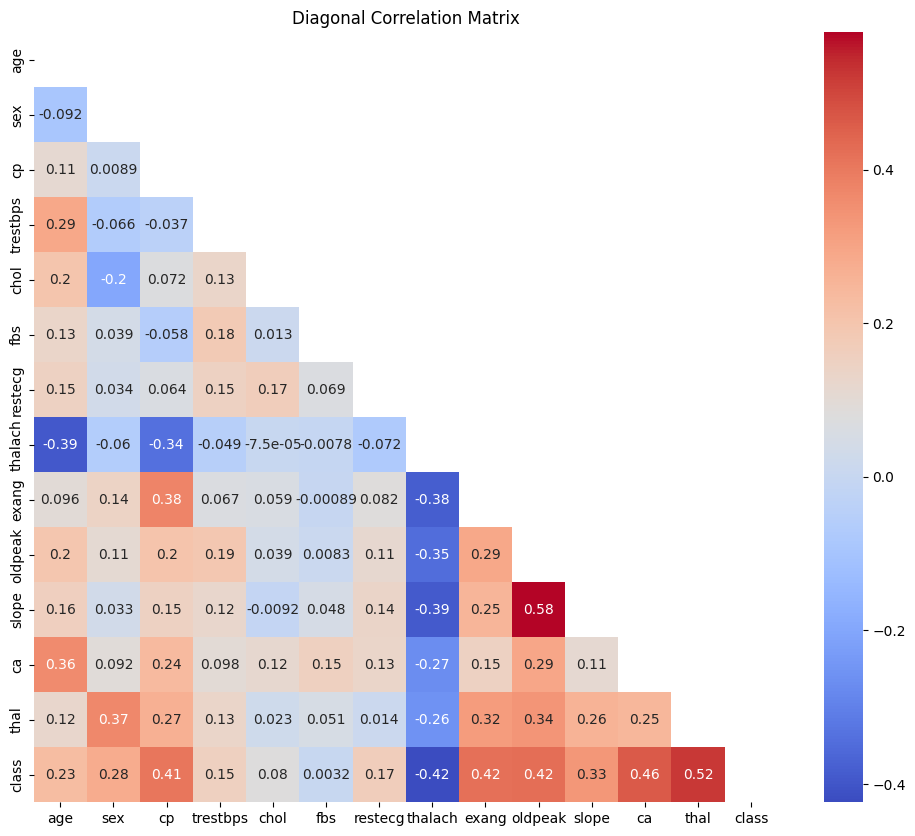

In [11]:
# Coorelation Matrix
corr = heart_data.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 10))
ax = sns.heatmap(corr, annot=True, mask=mask, cmap='coolwarm')

plt.title('Diagonal Correlation Matrix')
plt.show()

In [12]:
# Highest positively correlated features are thal,ca,oldpeak, exang, and cp (with correlation coefficients of 0.52, 0.46, 0.42, 0.43, and 0.41)
# Only one feature, thalach exhibits a notable negative correlation with the target variable (coefficient of -0.42)
# The feature fbs stands out as having minimal to negligible linear correlation with the target variable, as indicated by its correlation coefficient of 0.0.

In [13]:
# mapping categorical variables
heart_data['class'] = heart_data['class'].map({1: 'has disease', 0: 'no disease'})
heart_data['sex'] = heart_data['sex'].map({0:'Female', 1:'Male'})
heart_data['cp'] = heart_data['cp'].map({1:'Typical Angina', 2:'Atypical Angina', 3:'Non-anginal Pain',4:'Asymptomatic'})
heart_data['fbs'] = heart_data['fbs'].map({0:'<120 mg/dl', 1:'>120 mg/dl'})
heart_data['restecg'] = heart_data['restecg'].map({0: 'Normal', 1:'ST-T wave abnormality', 2:'Left ventricular hypertrophy'})
heart_data['exang'] = heart_data['exang'].map({0: 'No', 1:'Yes'})
heart_data['slope'] = heart_data['slope'].map({1: 'Uplsoping', 2:'Flat', 3:'Downsloping'})

heart_data['thal'] = heart_data['thal'].map({3: 'Normal', 6:'Fixed Defect',7:'Reversible Defect'})

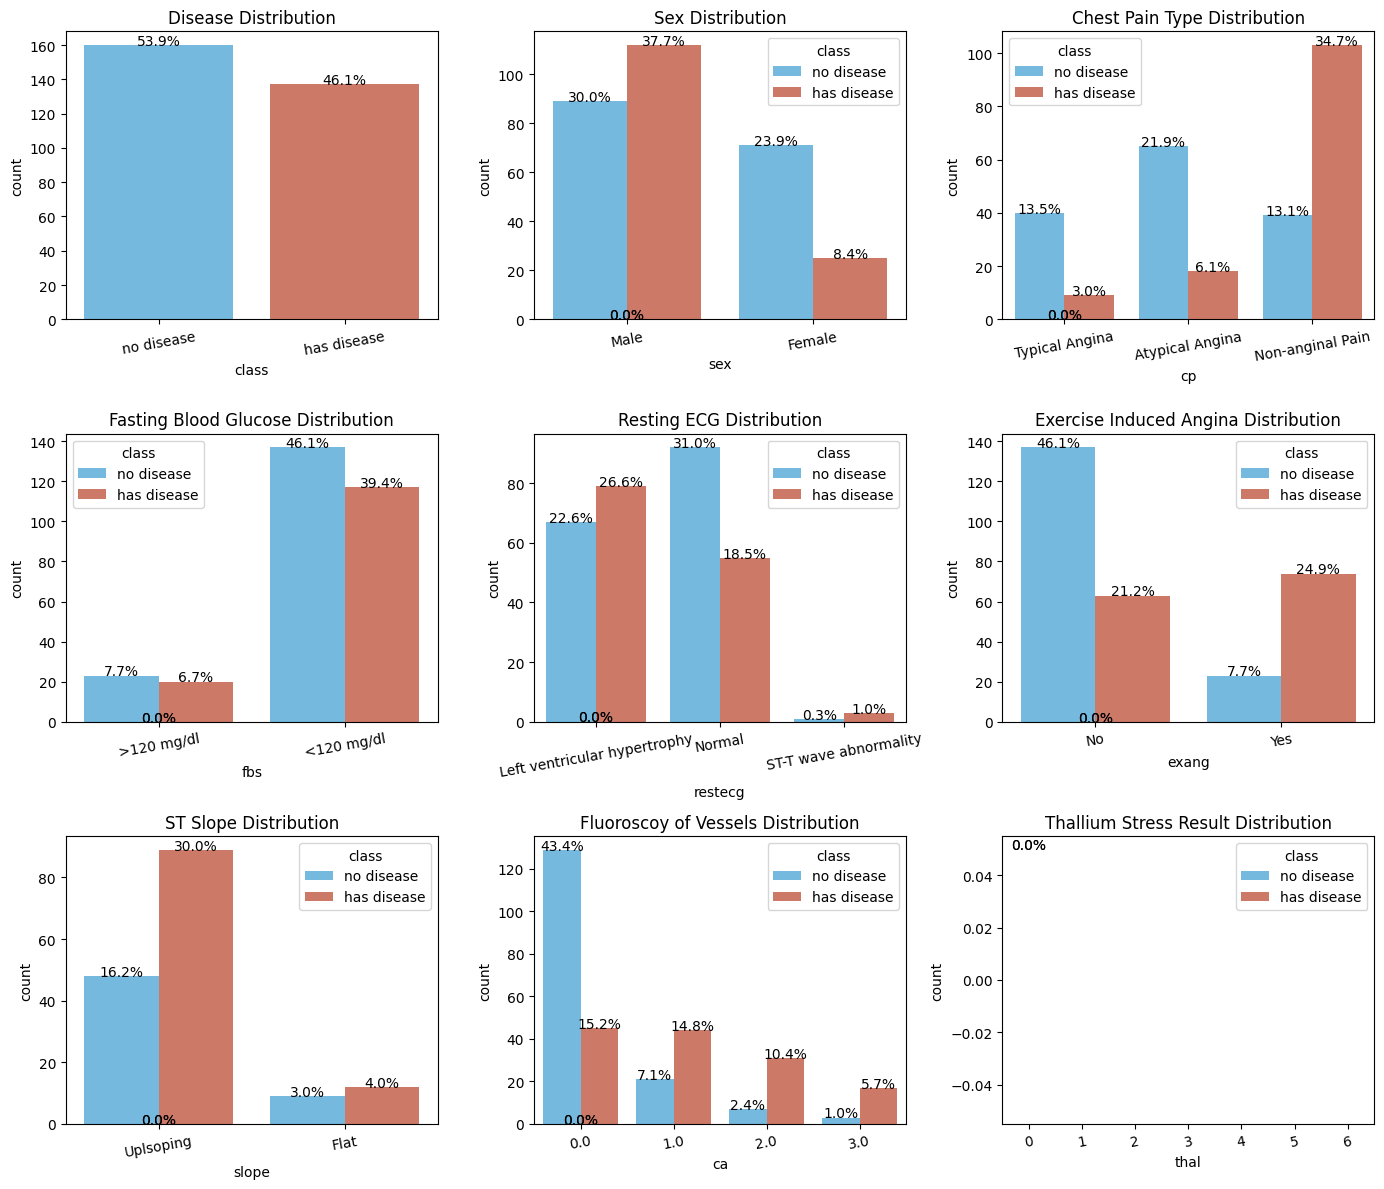

In [53]:
# Categorical Data Analysis

custom_palette = ['#63bff0','#de6e56']
def countplots_grid(df, variables, titles):

    fig, axes = plt.subplots(3, 3, figsize=(14, 12))

    for i, var in enumerate(variables):

        ax = axes[i//3, i%3]
        sns.countplot(x=var, hue='class', data=df, ax=ax, palette=custom_palette)

        ax.set_title(titles[i])
        ax.set_xticklabels(ax.get_xticklabels(), rotation=10)

        total = len(df[var])  # Total number of data points for the current variable

        for p in ax.patches:
            percentage = '{:.1f}%'.format(100 * p.get_height()/total)
            x = p.get_x() + p.get_width() / 2
            y = p.get_height() + 0.05
            ax.annotate(percentage, (x, y), ha='center')

    plt.savefig('count_plot.png')
    plt.tight_layout()
    plt.show()

variables = ['class', 'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

titles = ['Disease Distribution', 'Sex Distribution', 'Chest Pain Type Distribution',
          'Fasting Blood Glucose Distribution','Resting ECG Distribution',
          'Exercise Induced Angina Distribution', 'ST Slope Distribution', 'Fluoroscoy of Vessels Distribution',
          'Thallium Stress Result Distribution']

countplots_grid(heart_data, variables, titles)

In [15]:
# Male are more likely to have heart disease
# Most heart disease patients are asymptomatic (-0.41)
# Blood sugar has no relation to the heart disease (0.0)
# Patients with exercised induced angina are 3x more likely to have heart disease (0.41)
# Upslopping ST is associated with normal condition while flat ST is associated with heart disease
# Higher values of coloured major vessels are associated with heart disease (0.46)
# Detected defects in thallium stress test result is associated with heart disease (0.52)

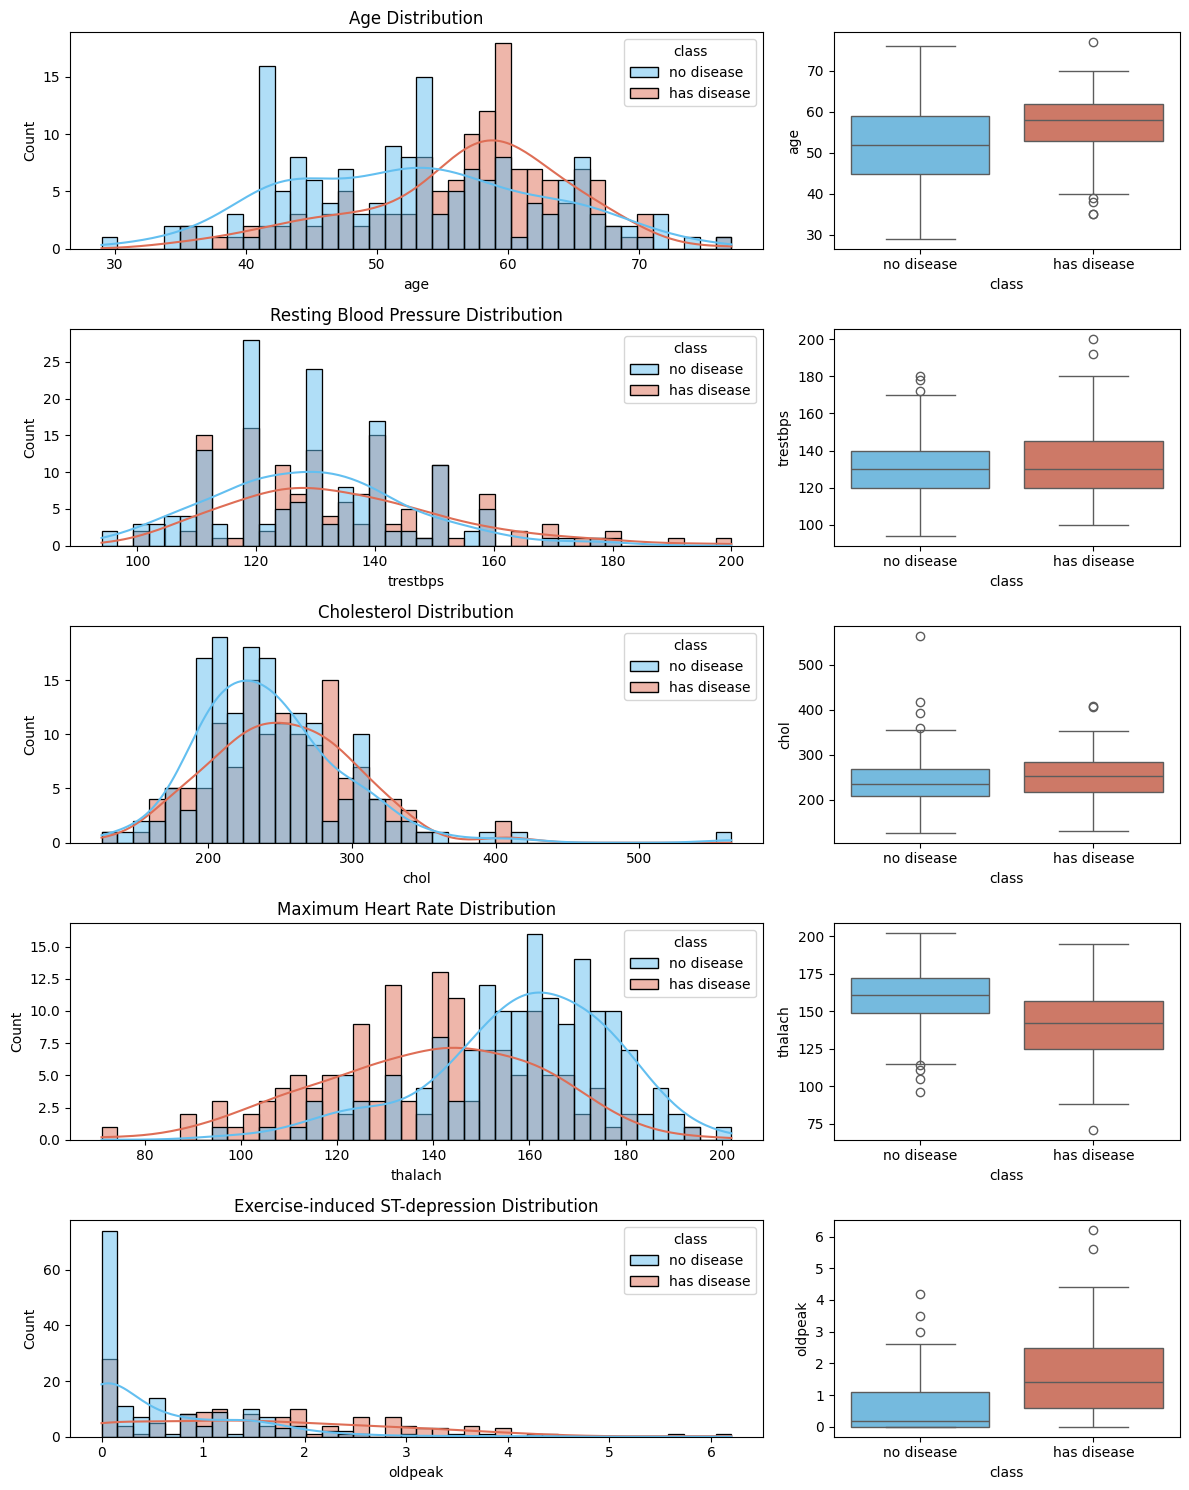

In [52]:
# Numerical Data Analysis

def num_plot_grid(df, attributes, titles, figsize=(12, 15)):

    fig, axes = plt.subplots(len(attributes), 2, figsize=figsize,
                             gridspec_kw={'width_ratios': [2, 1]})

    for i, attr in enumerate(attributes):

        sns.histplot(data=df, x=attr, kde=True, hue='class',
                     bins=40, palette=custom_palette, ax=axes[i,0])

        axes[i,0].set_title(titles[i])

        sns.boxplot(data=df, x='class', y=attr,palette=custom_palette, ax=axes[i,1])

    plt.savefig('grid_plot.png')
    plt.tight_layout()
    plt.show()


attributes = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
titles = ['Age Distribution', 'Resting Blood Pressure Distribution',
          'Cholesterol Distribution', 'Maximum Heart Rate Distribution', 'Exercise-induced ST-depression Distribution']

num_plot_grid(heart_data, attributes, titles)

In [17]:
# Older patient are more likely to have heart disease
# Lower heart rate is assoicated with heart disease (negative association, corr -0.42)
# Increased ST-depression level is associated with heart disease

<Figure size 640x480 with 0 Axes>

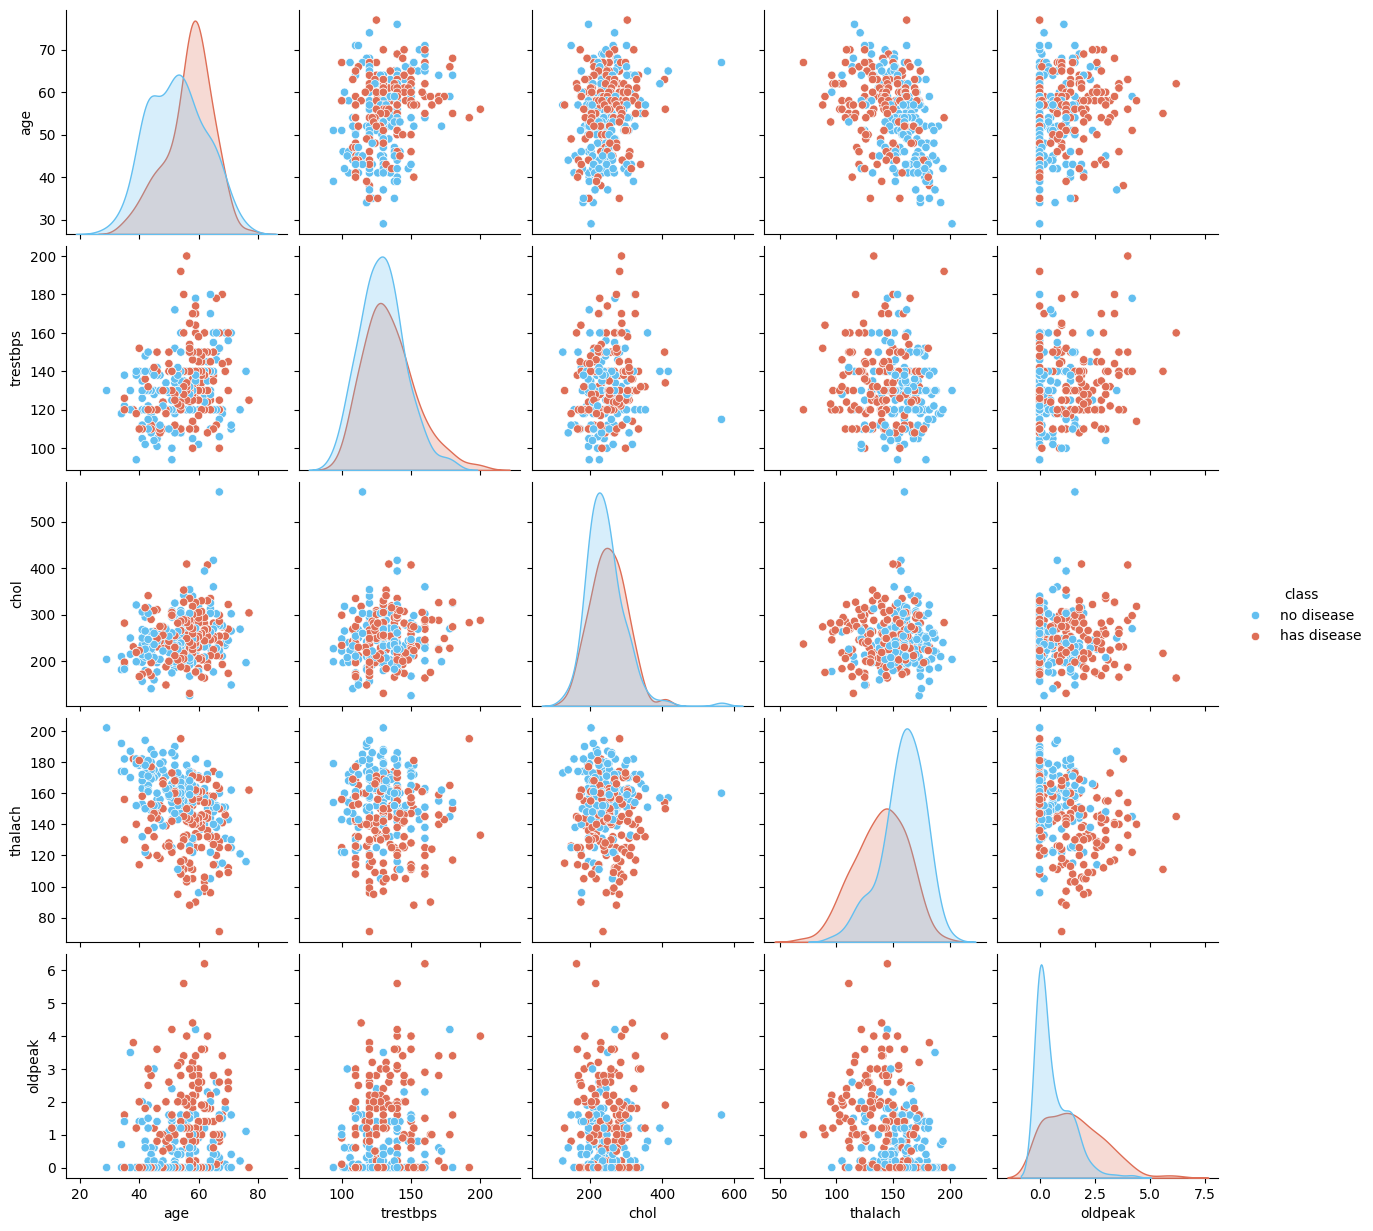

In [54]:
# pairplot

plt.figure()
sns.pairplot(heart_data[['age','trestbps','chol','thalach','oldpeak', 'class']], hue='class', palette=custom_palette
           #markers=['o','D'], plot_kws=dict(s=25, alpha=0.75, ci=None)
            )
plt.savefig('pairplot.png')
plt.show()


In [19]:
# Some overlaps found in variables in the features, which is 'chol' and 'trestbps'. Both features have similar distribution
# Features 'oldpeak', 'thalach', 'age' have most variation based target variable 'class'

In [20]:
# Modleing

In [21]:
# Splitting data in train and test sets
X = heart_data.drop('class', axis=1)
y = heart_data['class']

# Perform one-hot encoding on categorical features
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'] # List of categorical features
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore') # Create OneHotEncoder instance
encoded_data = encoder.fit_transform(X[categorical_features]) # Fit and transform categorical features
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_features)) # Create DataFrame from encoded data
X = X.drop(categorical_features, axis=1) # Drop original categorical features from X
X = pd.concat([X, encoded_df], axis=1) # Concatenate encoded features with X


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=1, stratify=y
)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)



(237, 23) (60, 23) (237,) (60,)


In [22]:
### Checking class balance for whole data, train set, validation set, and test set

print('shape of training set:', X_train.shape)
print('shape of test set:', X_test.shape, '\n')
print('Percentage of clauses in training set:',y_train.value_counts(normalize=True),'\n')
print('Percentage of clauses in test set:',y_test.value_counts(normalize=True))

shape of training set: (237, 23)
shape of test set: (60, 23) 

Percentage of clauses in training set: class
no disease     0.540084
has disease    0.459916
Name: proportion, dtype: float64 

Percentage of clauses in test set: class
no disease     0.533333
has disease    0.466667
Name: proportion, dtype: float64


In [23]:
###  Function to calculate different metric scores of the model - Accuracy, Recall and Precision
def get_metrics_score(model,flag=True):
    '''
    model : classifier to predict values of X

    '''
    score_list=[]

    #Predicting on train and tests
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    #Accuracy of the model
    train_acc = model.score(X_train,y_train)
    test_acc = model.score(X_test,y_test)

    #Recall of the model
    train_recall = metrics.recall_score(y_train,pred_train, pos_label='has disease') # Changed pos_label to 'has disease'
    test_recall = metrics.recall_score(y_test,pred_test, pos_label='has disease') # Changed pos_label to 'has disease'

    #Precision of the model
    train_precision = metrics.precision_score(y_train,pred_train, pos_label='has disease') # Changed pos_label to 'has disease'
    test_precision = metrics.precision_score(y_test,pred_test, pos_label='has disease') # Changed pos_label to 'has disease'

    # F1 of the model
    train_f1 = metrics.f1_score(y_train,pred_train, pos_label='has disease') # Changed pos_label to 'has disease'
    test_f1 = metrics.f1_score(y_test,pred_test, pos_label='has disease') # Changed pos_label to 'has disease'

    score_list.extend((train_acc,test_acc,train_recall,test_recall,train_precision,test_precision,train_f1,test_f1))

    if flag == True:
        print("Accuracy on training set : ",model.score(X_train,y_train))
        print("Accuracy on test set : ",model.score(X_test,y_test))
        print("Recall on training set : ",metrics.recall_score(y_train,pred_train, pos_label='has disease')) # Changed pos_label to 'has disease'
        print("Recall on test set : ",metrics.recall_score(y_test,pred_test, pos_label='has disease')) # Changed pos_label to 'has disease'
        print("Precision on training set : ",metrics.precision_score(y_train,pred_train, pos_label='has disease')) # Changed pos_label to 'has disease'
        print("Precision on test set : ",metrics.precision_score(y_test,pred_test, pos_label='has disease')) # Changed pos_label to 'has disease'
        print("F1 score on training set : ",metrics.f1_score(y_train,pred_train, pos_label='has disease')) # Changed pos_label to 'has disease'
        print("F1 score on test set : ",metrics.f1_score(y_test,pred_test, pos_label='has disease')) # Changed pos_label to 'has disease'

    return score_list # returning the list with train and test scores


In [24]:
## Function to create confusion matrix
def make_confusion_matrix(model,y_actual,labels=[1, 0]):
    '''
    model : classifier to predict values of X
    y_actual : ground truth

    '''
    y_predict = model.predict(X_test)
    cm=metrics.confusion_matrix( y_actual, y_predict, labels=[0, 1])
    df_cm = pd.DataFrame(cm, index = [i for i in ["Actual - No","Actual - Yes"]],
                  columns = [i for i in ['Predicted - No','Predicted - Yes']])
    group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in
                         cm.flatten()/np.sum(cm)]
    labels = [f"{v1}\n{v2}" for v1, v2 in
              zip(group_counts,group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    plt.figure(figsize = (10,7))
    sns.heatmap(df_cm, annot=labels,fmt='')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [25]:
dtree = DecisionTreeClassifier(random_state=1) ### Using Decision Tree Classifier

### training the decision tree model
dtree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

In [26]:
### Get score
Decision_tree_score = get_metrics_score(dtree)

Accuracy on training set :  1.0
Accuracy on test set :  0.7833333333333333
Recall on training set :  1.0
Recall on test set :  0.6785714285714286
Precision on training set :  1.0
Precision on test set :  0.8260869565217391
F1 score on training set :  1.0
F1 score on test set :  0.7450980392156863


In [27]:
rf_cl = RandomForestClassifier(random_state=1)
rf_cl.fit(X_train,y_train)

RandomForestClassifier(random_state=1)

In [28]:
Random_forest_score = get_metrics_score(rf_cl)

Accuracy on training set :  1.0
Accuracy on test set :  0.8833333333333333
Recall on training set :  1.0
Recall on test set :  0.8214285714285714
Precision on training set :  1.0
Precision on test set :  0.92
F1 score on training set :  1.0
F1 score on test set :  0.8679245283018868


In [29]:
dtree_estimator = DecisionTreeClassifier(class_weight="balanced", random_state=1)

parameters = {
    "max_depth": np.arange(10, 30, 5),
    "min_samples_leaf": [3, 5, 7],
    "max_leaf_nodes": [2, 3, 5],
    "min_impurity_decrease": [0.0001, 0.001],
}

scorer = metrics.make_scorer(metrics.recall_score)

grid_obj = GridSearchCV(dtree_estimator, parameters, scoring=scorer, n_jobs=-1, cv=5)

grid_obj = grid_obj.fit(X_train, y_train)

dtree_estimator = grid_obj.best_estimator_

dtree_estimator.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=np.int64(10),
                       max_leaf_nodes=2, min_impurity_decrease=0.0001,
                       min_samples_leaf=3, random_state=1)

In [30]:
### Get score
dtree_estimator_score = get_metrics_score(dtree_estimator)

Accuracy on training set :  0.7552742616033755
Accuracy on test set :  0.75
Recall on training set :  0.7614678899082569
Recall on test set :  0.7142857142857143
Precision on training set :  0.7217391304347827
Precision on test set :  0.7407407407407407
F1 score on training set :  0.7410714285714286
F1 score on test set :  0.7272727272727273


In [31]:
### Choosing the best classsifer
rfcls_tuned = RandomForestClassifier(class_weight='balanced',random_state=1)

params = { "n_estimators": np.arange(50, 100, 150),
           'min_samples_split': [3,5,7],
           "max_features": [0.3,0.5,0.7,1],
            "max_samples": np.arange(0.3, 0.7, 0.1),
          }

acc_scr = metrics.make_scorer(metrics.recall_score)

grid_obj = GridSearchCV(rfcls_tuned, params, scoring=acc_scr,cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

rfcls_tuned = grid_obj.best_estimator_
print(rfcls_tuned)

RandomForestClassifier(class_weight='balanced', max_features=0.3,
                       max_samples=np.float64(0.3), min_samples_split=3,
                       n_estimators=np.int64(50), random_state=1)


In [32]:
### Get Score
rfcls_tuned_score = get_metrics_score(rfcls_tuned)

Accuracy on training set :  0.8776371308016878
Accuracy on test set :  0.75
Recall on training set :  0.8348623853211009
Recall on test set :  0.6428571428571429
Precision on training set :  0.8921568627450981
Precision on test set :  0.782608695652174
F1 score on training set :  0.8625592417061612
F1 score on test set :  0.7058823529411765


In [33]:
### Fit smote
smote = SMOTE(sampling_strategy= 'auto', k_neighbors=5,random_state=1)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)

In [34]:
dtree1 = DecisionTreeClassifier(random_state=1) ### Using Decision Tree Classifier

dtree1.fit(X_train_over, y_train_over)

DecisionTreeClassifier(random_state=1)

In [35]:
### Score
Decision_tree_score_over = get_metrics_score(dtree1)

Accuracy on training set :  1.0
Accuracy on test set :  0.7666666666666667
Recall on training set :  1.0
Recall on test set :  0.6785714285714286
Precision on training set :  1.0
Precision on test set :  0.7916666666666666
F1 score on training set :  1.0
F1 score on test set :  0.7307692307692307


In [36]:
rf_cl1 = RandomForestClassifier(random_state=1)
rf_cl1.fit(X_train_over,y_train_over)

RandomForestClassifier(random_state=1)

In [37]:
Random_forest_score_over = get_metrics_score(rf_cl1)

Accuracy on training set :  1.0
Accuracy on test set :  0.8666666666666667
Recall on training set :  1.0
Recall on test set :  0.8214285714285714
Precision on training set :  1.0
Precision on test set :  0.8846153846153846
F1 score on training set :  1.0
F1 score on test set :  0.8518518518518519


In [38]:
dtree_estimator = DecisionTreeClassifier(class_weight="balanced", random_state=1)

parameters = {
    "max_depth": np.arange(10, 30, 5),
    "min_samples_leaf": [3, 5, 7],
    "max_leaf_nodes": [2, 3, 5],
    "min_impurity_decrease": [0.0001, 0.001],
}

scorer = metrics.make_scorer(metrics.recall_score) ### Choosing F1 score since it balances precision and recall

grid_obj = GridSearchCV(dtree_estimator, parameters, scoring=scorer, n_jobs=-1)

grid_obj = grid_obj.fit(X_train_over, y_train_over)

dtree_estimator = grid_obj.best_estimator_

dtree_estimator.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=np.int64(10),
                       max_leaf_nodes=2, min_impurity_decrease=0.0001,
                       min_samples_leaf=3, random_state=1)

In [39]:
### Get score
dtree_estimator_score = get_metrics_score(dtree_estimator)

Accuracy on training set :  0.7552742616033755
Accuracy on test set :  0.75
Recall on training set :  0.7614678899082569
Recall on test set :  0.7142857142857143
Precision on training set :  0.7217391304347827
Precision on test set :  0.7407407407407407
F1 score on training set :  0.7410714285714286
F1 score on test set :  0.7272727272727273


In [40]:
rfcls_tuned = RandomForestClassifier(class_weight='balanced',random_state=1)

params = { "n_estimators": np.arange(50, 100, 150),
           'min_samples_split': [3,5,7],
           "max_features": [0.3,0.5,0.7,1],
            "max_samples": np.arange(0.3, 0.7, 0.1),
          }

acc_scr = metrics.make_scorer(metrics.f1_score)

grid_obj = GridSearchCV(rfcls_tuned, params, scoring=acc_scr,cv=5,n_jobs=-1) ### Runing grid search to find the best estimator
grid_obj = grid_obj.fit(X_train_over, y_train_over)


rfcls_tuned = grid_obj.best_estimator_
print(rfcls_tuned)

rfcls_tuned.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_features=0.3,
                       max_samples=np.float64(0.3), min_samples_split=3,
                       n_estimators=np.int64(50), random_state=1)


RandomForestClassifier(class_weight='balanced', max_features=0.3,
                       max_samples=np.float64(0.3), min_samples_split=3,
                       n_estimators=np.int64(50), random_state=1)

In [41]:
### Get Score
rfcls_tuned_score = get_metrics_score(rfcls_tuned)

Accuracy on training set :  0.8776371308016878
Accuracy on test set :  0.75
Recall on training set :  0.8348623853211009
Recall on test set :  0.6428571428571429
Precision on training set :  0.8921568627450981
Precision on test set :  0.782608695652174
F1 score on training set :  0.8625592417061612
F1 score on test set :  0.7058823529411765


In [42]:
knn = KNeighborsClassifier()

param_grid = {'n_neighbors': [3, 5, 7, 9],
              'weights': ['uniform', 'distance'],
              'metric': ['euclidean', 'manhattan']}

grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='recall')
grid_search.fit(X_train, y_train)

best_knn = grid_search.best_estimator_

knn_score = get_metrics_score(best_knn)

Accuracy on training set :  0.7805907172995781
Accuracy on test set :  0.6333333333333333
Recall on training set :  0.7339449541284404
Recall on test set :  0.5357142857142857
Precision on training set :  0.7766990291262136
Precision on test set :  0.625
F1 score on training set :  0.7547169811320755
F1 score on test set :  0.5769230769230769


In [43]:
svm = SVC(kernel='linear', class_weight='balanced', random_state=1)

param_grid = {'C': [0.1, 1, 10]}

grid_search = GridSearchCV(svm, param_grid, cv=3, scoring='recall', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_svm = grid_search.best_estimator_

svm_score = get_metrics_score(best_svm)

Accuracy on training set :  0.8396624472573839
Accuracy on test set :  0.8833333333333333
Recall on training set :  0.7614678899082569
Recall on test set :  0.75
Precision on training set :  0.8736842105263158
Precision on test set :  1.0
F1 score on training set :  0.8137254901960784
F1 score on test set :  0.8571428571428571


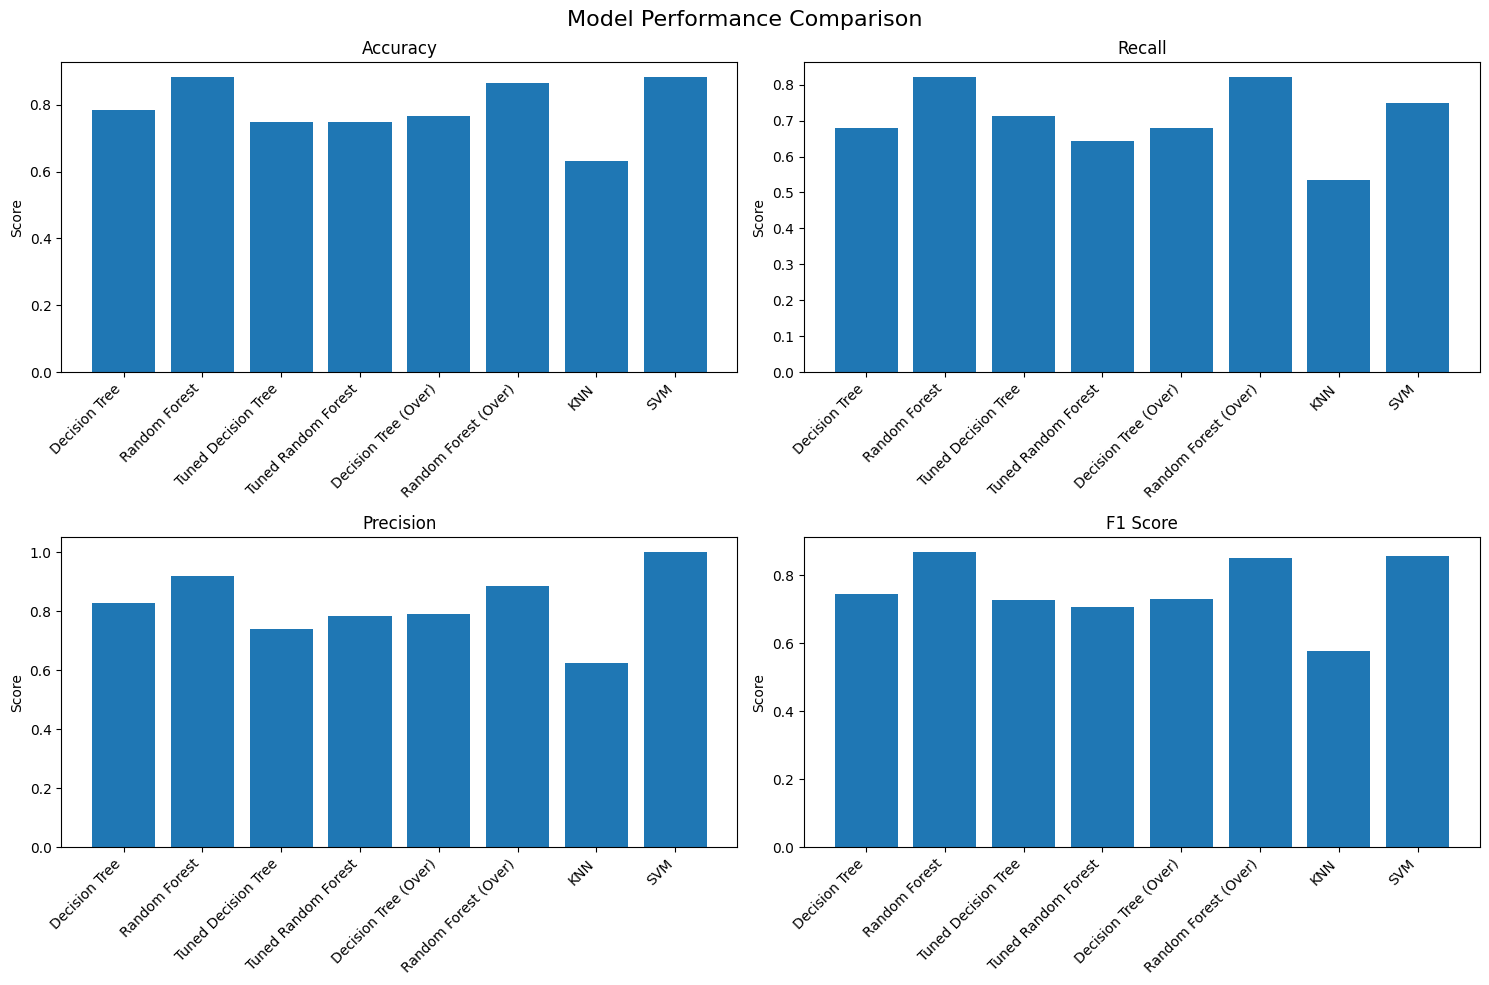

In [55]:
import matplotlib.pyplot as plt
import numpy as np

# Create a list of model names
model_names = ['Decision Tree', 'Random Forest', 'Tuned Decision Tree', 'Tuned Random Forest', 'Decision Tree (Over)', 'Random Forest (Over)', 'KNN', 'SVM']

# Extract Accuracy, Recall, Precision, and F1 scores for each model
accuracy_scores = [score[1] for score in [Decision_tree_score, Random_forest_score, dtree_estimator_score, rfcls_tuned_score, Decision_tree_score_over, Random_forest_score_over, knn_score, svm_score]]
recall_scores = [score[3] for score in [Decision_tree_score, Random_forest_score, dtree_estimator_score, rfcls_tuned_score, Decision_tree_score_over, Random_forest_score_over, knn_score, svm_score]]
precision_scores = [score[5] for score in [Decision_tree_score, Random_forest_score, dtree_estimator_score, rfcls_tuned_score, Decision_tree_score_over, Random_forest_score_over, knn_score, svm_score]]
f1_scores = [score[7] for score in [Decision_tree_score, Random_forest_score, dtree_estimator_score, rfcls_tuned_score, Decision_tree_score_over, Random_forest_score_over, knn_score, svm_score]]

# Create subplots for each metric
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Model Performance Comparison', fontsize=16)

# Accuracy Plot
axes[0, 0].bar(model_names, accuracy_scores)
axes[0, 0].set_title('Accuracy')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_xticklabels(model_names, rotation=45, ha='right')

# Recall Plot
axes[0, 1].bar(model_names, recall_scores)
axes[0, 1].set_title('Recall')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_xticklabels(model_names, rotation=45, ha='right')

# Precision Plot
axes[1, 0].bar(model_names, precision_scores)
axes[1, 0].set_title('Precision')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_xticklabels(model_names, rotation=45, ha='right')

# F1 Score Plot
axes[1, 1].bar(model_names, f1_scores)
axes[1, 1].set_title('F1 Score')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_xticklabels(model_names, rotation=45, ha='right')

# Adjust layout and display the plot
plt.tight_layout()
plt.savefig('model_performance_comparison.png')
plt.show()


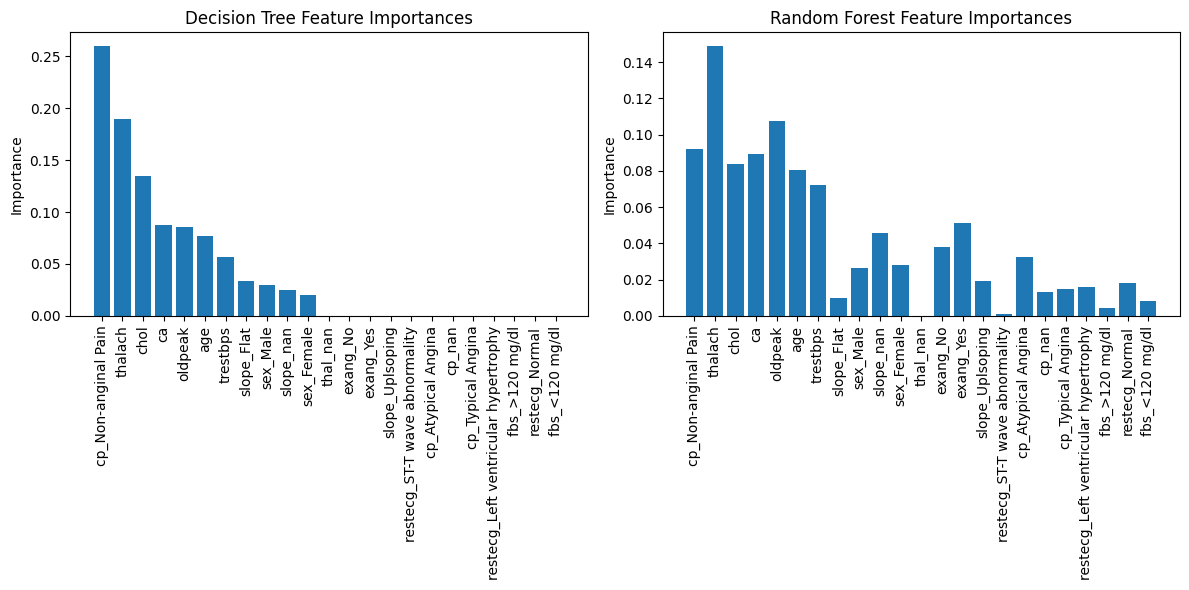

In [57]:


# Get feature importances
dtree_importances = dtree.feature_importances_
rf_importances = rf_cl.feature_importances_

indices = np.argsort(dtree_importances)[::-1]

names = [X.columns[i] for i in indices]

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Decision Tree Feature Importances")
plt.bar(range(X.shape[1]), dtree_importances[indices])
plt.xticks(range(X.shape[1]), names, rotation=90)
plt.ylabel("Importance")

# Random Forest feature importances
plt.subplot(1, 2, 2)
plt.title("Random Forest Feature Importances")
plt.bar(range(X.shape[1]), rf_importances[indices])
plt.xticks(range(X.shape[1]), names, rotation=90)
plt.ylabel("Importance")

plt.tight_layout()
plt.savefig('feature_importance_random_forest_decision_tree.png')
plt.show()


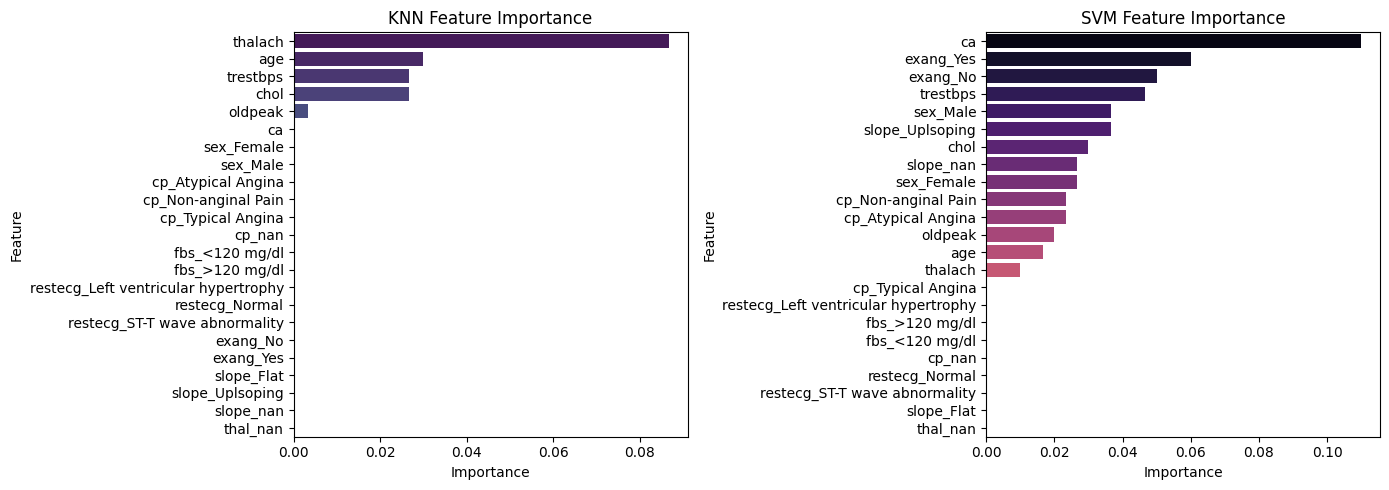

In [56]:
!pip install eli5
import eli5

from eli5.sklearn import PermutationImportance

# For KNN
perm_knn = PermutationImportance(best_knn, random_state=1).fit(X_test, y_test)
eli5.show_weights(perm_knn, feature_names = X.columns.tolist())

# For SVM
perm_svm = PermutationImportance(best_svm, random_state=1).fit(X_test, y_test)
eli5.show_weights(perm_svm, feature_names = X.columns.tolist())


# Extract feature importance values
knn_importance = perm_knn.feature_importances_
svm_importance = perm_svm.feature_importances_

feature_names = X_test.columns.tolist()  # Ensure X_test is a DataFrame

knn_df = pd.DataFrame({'Feature': feature_names, 'Importance': knn_importance}).sort_values(by='Importance', ascending=False)
svm_df = pd.DataFrame({'Feature': feature_names, 'Importance': svm_importance}).sort_values(by='Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=knn_df, x='Importance', y='Feature', ax=axes[0], palette="viridis")
axes[0].set_title('KNN Feature Importance')

sns.barplot(data=svm_df, x='Importance', y='Feature', ax=axes[1], palette="magma")
axes[1].set_title('SVM Feature Importance')

plt.tight_layout()
plt.savefig('feature_importance_knn_and_svm.png')
plt.show()
